In [261]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

In [1]:
site = 1
y
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states[dat_states.PERIOD .< 50,:]
testing = dat_states[(dat_states.PERIOD .>= 50) .& (dat_states.PERIOD .<= 55),:]
validation = dat_states[dat_states.PERIOD .> 55,:]

X = dat[dat.SITE .== site,[:PERIOD,:MesFra,:StrPur,:PteCal,:PycHel,:SemPul]]

p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
Plots.plot!(X.PERIOD, X.PycHel, label = "PycHel", width = 2, color = "#f06718" )
plot(p1,p2, layout = (2,1), size = (1000,500))

LoadError: UndefVarError: `y` not defined

In [293]:
X[1:2,:]

Row,PERIOD,MesFra,StrPur,PteCal,PycHel,SemPul
,Int64,Float64,Float64,Float64,Float64,Float64
1,3,-0.365357,-1.76121,1.27828,-0.687318,-0.605876
2,4,-0.410469,-1.28724,1.1604,-0.687318,-0.551572


In [294]:
covars = []

NN, NNparameters = UniversalDiffEq.SimpleNeuralNetwork(2+length(covars),2, hidden = 10, seed = 5491)

function dudt(u,X,p,t,covars)
    return NN(vcat(u,X[covars]), p.NN) # index 3 is pycnopodia  ,X[1:2]
end

init_parameters = (NN = NNparameters, )

NODE = UniversalDiffEq.CustomDerivatives(training,X,(u,X,p,t) -> dudt(u,X,p,t,covars),
                                            init_parameters;time_column_name = "PERIOD")

UniversalDiffEq.train!(NODE, loss_function = "spline gradient matching", 
        regularization_weight = 100, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.1, T = 4*size(training)[1]))
nothing

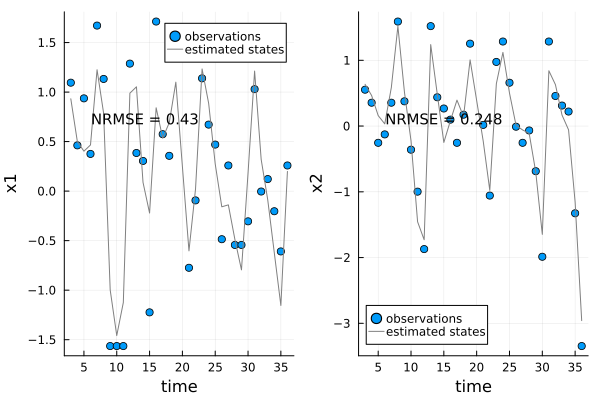

In [295]:
UniversalDiffEq.plot_state_estimates(NODE)

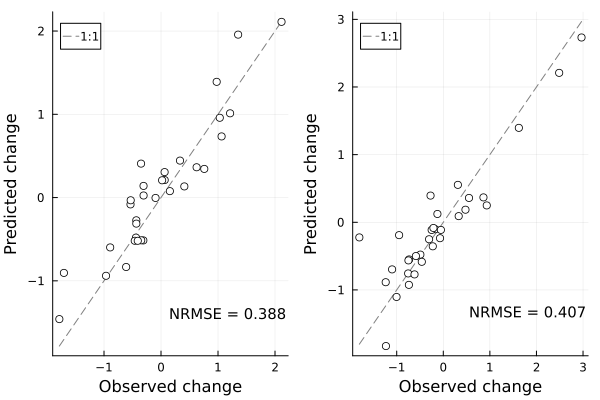

In [296]:
UniversalDiffEq.plot_predictions(NODE)

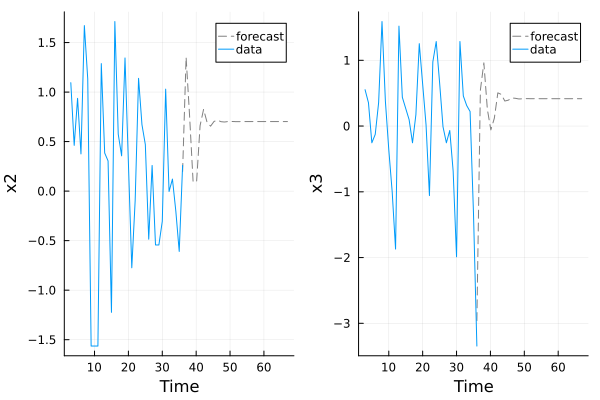

In [297]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(NODE, 30)
plt

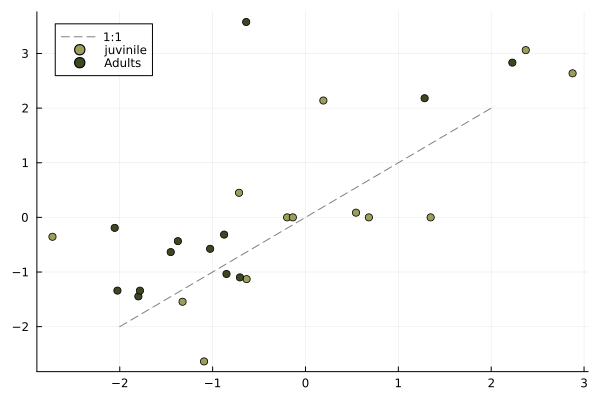

In [298]:
using StatsBase
function test_metrics(model,testing) 
    inits,obs,preds = UniversalDiffEq.predictions(model,testing)
    delta_obs = obs .- inits
    delta_pred = preds .- inits

    plt = Plots.plot([-2,2],[-2,2], color = "grey", linestyle = :dash, label = "1:1")
    Plots.scatter!(delta_pred[1,:], delta_obs[1,:], color = "#9d9e59", label = "juvinile")
    Plots.scatter!(delta_pred[2,:], delta_obs[2,:], color = "#3d4722", label = "Adults")

    cor_juv = cor(delta_obs[1,:], delta_pred[1,:])
    cor_adult =cor(delta_obs[2,:], delta_pred[2,:])
    return cor_juv, cor_adult, plt
end

c1,c2,plt=test_metrics(NODE,testing)
println("juvinile growth: ", c1)
println("Adult growth: ", c2)
plt 

In [299]:
rhs = UniversalDiffEq.get_right_hand_side(NODE)

#321 (generic function with 1 method)

In [300]:
u = [0.0,0.0]
X = [0.0,0.0,0.0,0.0,0.0]
rhs(u,X,0.0)

2-element Vector{Float64}:
  0.09255451837057174
 -0.2570699725146592

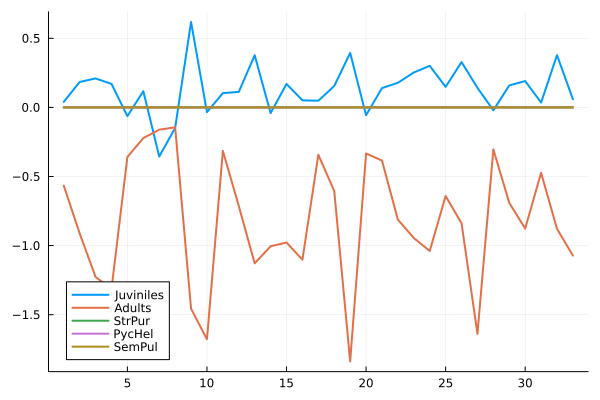

In [301]:

using ForwardDiff


function transform(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale)
    u = log.((y.-mean)./scale)
    X = u[3:end]
    print(X)
    u = u[1:2]
    dydu = scale_y.*exp.(u)
    dudt = rhs(u,X,0.0)
    return dydu.*dudt./y[1:2]
end 


function percap_growth_jacobian(y,mean,scale)
    f = y ->  percap_growth(y,mean,scale)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,1,2,3,5,7]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end


scale, means = get_scaling_factors(4)
obs = size(NODE.parameters.uhat)[2]
effects_juv = zeros(obs,7)
effects_adults = zeros(obs,7)
for i in 1:size(NODE.parameters.uhat)[2]
    u = vcat(NODE.parameters.uhat[:,i],Vector(NODE.X[i,2:end]))
    y = transform(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 
Plots.plot(effects_juv[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_juv[:,2], width = 2, label = "Adults")
Plots.plot!(effects_juv[:,4], width = 2, label = "StrPur")
Plots.plot!(effects_juv[:,6], width = 2, label = "PycHel")
Plots.plot!(effects_juv[:,7], width = 2, label = "SemPul")

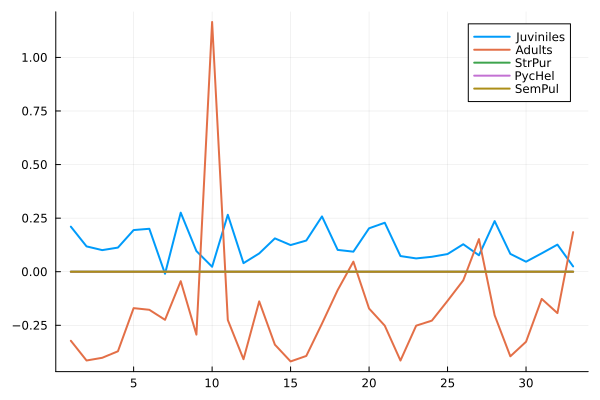

In [302]:
Plots.plot(effects_adults[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_adults[:,2], width = 2, label = "Adults")
Plots.plot!(effects_adults[:,4], width = 2, label = "StrPur")
Plots.plot!(effects_adults[:,6], width = 2, label = "PycHel")
Plots.plot!(effects_adults[:,7], width = 2, label = "SemPul")

In [303]:
mapslices(mean,effects_adults,dims=1)

1×7 Matrix{Float64}:
 0.124762  -0.177677  0.0  0.0  0.0  0.0  0.0

In [304]:
mapslices(mean,effects_juv,dims=1)

1×7 Matrix{Float64}:
 0.131512  -0.818105  0.0  0.0  0.0  0.0  0.0

In [305]:
println(NODE.parameters.uhat'[1,:])
println(Vector(NODE.X[1,2:5]))

In [306]:
scaleing_factors[:,1:3]

Row,Species,SITE,mean
,String7,Int64,Float64
1,MesFra,4,5.79208
2,StrPur,4,6.37144
3,PycHel,4,0.710761
4,MacJuv,4,2.77039
5,PteCal,4,2.22348
6,MacPyr,4,3.31321
7,SemPul,4,4.97263
